# Detect once, then cluster per-detection RPSDs

This notebook tests a two-resolution unsupervised workflow:

1. run one ordinary rank-one ALS/KLT detector on the untouched raw ROI using
   the best detection setting, `max_d=7`;
2. retain 51 NMS peaks, equal to the aggregated molecular count in this
   controlled simulation;
3. extract one centered \(33^3\) patch per detection from the detector's
   whitened tomogram;
4. re-estimate every detected patch's individual RPSD using `max_d=12`, which
   has greater low-frequency resolution;
5. cluster the same standardized RPSD features in two ways:
   - K-means directly, without PCA;
   - PCA retaining 95% variance, followed by the same K-means.

Both branches use \(K=7\), the number of simulated molecule classes. Ground
truth is not used for detection, RPSD estimation, PCA, or clustering. It is used
only afterward to label matched detections and evaluate the anonymous clusters.

The detected-patch features preserve both:

- normalized log-RPSD shape over the low-frequency band;
- log total RPSD power as one additional standardized feature.

Unmatched detections remain in clustering and are displayed as an eighth
post-hoc `unmatched` category rather than being removed in advance.

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.preprocessing import StandardScaler

from kltpicker_3d.utils import generate_uniform_radial_sampling_points
from tomotwin_iterative_masking_experiment import (
    CLASS_DIAMETERS,
    CLASS_NAMES,
    FixedGeometryRPSDEstimator,
    load_roi_and_gt,
    make_detector,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path("data/tomotwin_2df7")
DETECTION_MAX_DISTANCE = 7
CHARACTERIZATION_MAX_DISTANCE = 12
DETECTION_COUNT = 51
CHARACTERIZATION_PATCH_SIZE = 33
CLUSTER_COUNT = 7
FEATURE_MAX_FREQUENCY_FRACTION = 0.45
RANDOM_SEED = 7

OUTPUT_CSV = Path("tomotwin_detect_then_cluster_assignments.csv")
OUTPUT_NPZ = Path("tomotwin_detect_then_cluster_rpsds.npz")

print("JAX:", jax.__version__)
print("JAX devices:", jax.devices())

JAX: 0.10.2
JAX devices: [CpuDevice(id=0)]


## 1. Detect 51 candidates once on the untouched raw ROI

In [2]:
raw_roi, gt_by_class, supported_gt_by_class = load_roi_and_gt(DATA_DIR)
assert sum(len(gt_by_class[label]) for label in CLASS_NAMES) == DETECTION_COUNT

detector = make_detector(
    raw_roi,
    max_distance=DETECTION_MAX_DISTANCE,
    num_particles=DETECTION_COUNT,
)
start = time.perf_counter()
returned_count, picks = detector.process_tomogram()
detection_seconds = time.perf_counter() - start

if returned_count != DETECTION_COUNT:
    raise RuntimeError(
        f"Expected {DETECTION_COUNT} detections, received {returned_count}"
    )
if detector.whitened_tomogram is None:
    raise RuntimeError("Detector did not retain its whitened tomogram")

print(
    f"Detection finished in {detection_seconds:.1f} s; "
    f"score shape={detector.score_mat.shape}; picks={returned_count}."
)
display(pd.DataFrame({
    "class": CLASS_NAMES,
    "centers in ROI": [len(gt_by_class[label]) for label in CLASS_NAMES],
    "fully supported": [
        len(supported_gt_by_class[label]) for label in CLASS_NAMES
    ],
}))

Detection finished in 9.7 s; score shape=(100, 100, 100); picks=51.


,class,centers in ROI,fully supported
0,1avo,8,5
1,1e9r,5,2
2,1fpy,4,1
3,1fzg,9,5
4,1jz8,4,0
5,1oao,9,1
6,2df7,12,7


## 2. Post-hoc labels for evaluation only

One global Hungarian assignment matches detections to GT centers. A match is
valid only when its distance is within half of that GT molecule's TomoTwin
evaluation-box diameter. Detections without a valid assignment are labeled
`unmatched`.

In [3]:
def posthoc_detection_labels(picks, gt_by_class):
    gt_centers = np.concatenate(
        [gt_by_class[label] for label in CLASS_NAMES], axis=0
    )
    gt_labels = np.concatenate(
        [np.repeat(label, len(gt_by_class[label])) for label in CLASS_NAMES]
    )
    tolerances = np.array(
        [0.5 * CLASS_DIAMETERS[str(label)] for label in gt_labels],
        dtype=float,
    )
    distances = cdist(picks[:, :3], gt_centers)
    valid = distances <= tolerances[None, :]
    invalid_cost = (
        max(len(picks), len(gt_centers)) + 1
    ) * (float(tolerances.max()) + 1)
    costs = np.where(valid, distances, invalid_cost)
    pick_indices, gt_indices = linear_sum_assignment(costs)

    labels = np.full(len(picks), "unmatched", dtype=object)
    matched_distances = np.full(len(picks), np.nan, dtype=float)
    assigned = distances[pick_indices, gt_indices]
    accepted = assigned <= tolerances[gt_indices]
    labels[pick_indices[accepted]] = gt_labels[gt_indices[accepted]]
    matched_distances[pick_indices[accepted]] = assigned[accepted]
    return labels, matched_distances


posthoc_labels, match_distances = posthoc_detection_labels(picks, gt_by_class)
posthoc_counts = (
    pd.Series(posthoc_labels)
    .value_counts()
    .reindex(CLASS_NAMES + ["unmatched"], fill_value=0)
    .rename_axis("post-hoc label")
    .to_frame("detections")
)
display(posthoc_counts)

,detections
post-hoc label,
1avo,4
1e9r,3
1fpy,3
1fzg,6
1jz8,2
1oao,6
2df7,12
unmatched,15


## 3. Higher-resolution RPSD for every detected patch

The detector's whitened tomogram is reflect-padded so every peak, including
edge-adjacent peaks, yields the same \(33^3\) patch. The characterization RPSDs
use `max_d=12` and 33 common radial-frequency samples from zero to Nyquist.

In [4]:
def extract_centered_patches(volume, centers, patch_size):
    half = patch_size // 2
    padded = np.pad(np.asarray(volume), half, mode="reflect")
    patches = []
    integer_centers = np.rint(centers[:, :3]).astype(int)
    for center in integer_centers:
        shifted = center + half
        slices = tuple(
            slice(int(axis_center - half), int(axis_center + half + 1))
            for axis_center in shifted
        )
        patch = padded[slices]
        if patch.shape != (patch_size,) * 3:
            raise RuntimeError(f"Unexpected extracted patch shape {patch.shape}")
        patches.append(patch)
    return np.stack(patches).astype(np.float32)


detected_patches = extract_centered_patches(
    np.asarray(detector.whitened_tomogram),
    picks,
    CHARACTERIZATION_PATCH_SIZE,
)
detected_patches -= detected_patches.mean(
    axis=(1, 2, 3), keepdims=True
)

spectrum_size = 2 * CHARACTERIZATION_PATCH_SIZE - 1
radial_points, shell_ids, shell_counts = (
    generate_uniform_radial_sampling_points(spectrum_size, np.pi)
)
rpsd_estimator = FixedGeometryRPSDEstimator(
    CHARACTERIZATION_PATCH_SIZE,
    CHARACTERIZATION_MAX_DISTANCE,
    shell_ids,
    shell_counts,
    len(radial_points),
)

start = time.perf_counter()
detected_rpsds = rpsd_estimator.estimate(detected_patches)
rpsd_seconds = time.perf_counter() - start

if detected_rpsds.shape != (DETECTION_COUNT, len(radial_points)):
    raise RuntimeError(f"Unexpected RPSD matrix shape {detected_rpsds.shape}")

print(
    f"Estimated {len(detected_rpsds)} per-detection RPSDs at max_d="
    f"{CHARACTERIZATION_MAX_DISTANCE} in {rpsd_seconds:.1f} s."
)
print("RPSD matrix shape:", detected_rpsds.shape)

Estimated 51 per-detection RPSDs at max_d=12 in 1.0 s.
RPSD matrix shape: (51, 33)


## 4. Identical features for both clustering branches

Used 15 low-frequency bins through 0.45π plus one log-power feature.
Standardized feature shape: (51, 16)


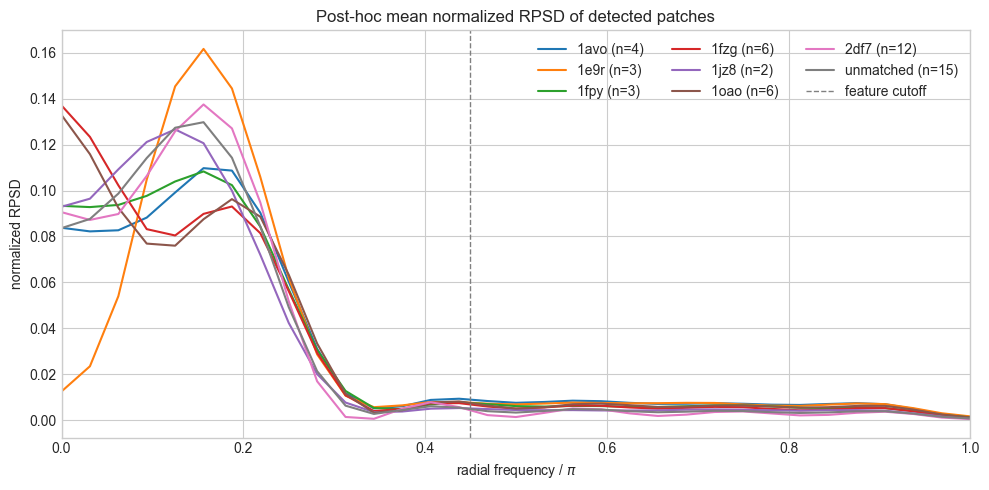

In [5]:
frequency_mask = (
    radial_points / np.pi <= FEATURE_MAX_FREQUENCY_FRACTION
)
low_frequency_rpsds = detected_rpsds[:, frequency_mask]

total_power = np.sum(detected_rpsds, axis=1)
shape = low_frequency_rpsds / np.maximum(
    low_frequency_rpsds.sum(axis=1, keepdims=True), 1e-20
)
log_shape = np.log(shape + 1e-8)
log_total_power = np.log(total_power + 1e-20)[:, None]
unscaled_features = np.concatenate([log_shape, log_total_power], axis=1)

scaler = StandardScaler()
standardized_features = scaler.fit_transform(unscaled_features)

print(
    f"Used {frequency_mask.sum()} low-frequency bins through "
    f"{FEATURE_MAX_FREQUENCY_FRACTION:.2f}π plus one log-power feature."
)
print("Standardized feature shape:", standardized_features.shape)

fig, ax = plt.subplots(figsize=(10, 5))
for label in CLASS_NAMES + ["unmatched"]:
    members = posthoc_labels == label
    if np.any(members):
        mean_curve = np.mean(
            detected_rpsds[members]
            / np.maximum(detected_rpsds[members].sum(axis=1, keepdims=True), 1e-20),
            axis=0,
        )
        ax.plot(radial_points / np.pi, mean_curve, label=f"{label} (n={members.sum()})")
ax.axvline(
    FEATURE_MAX_FREQUENCY_FRACTION,
    color="grey",
    linestyle="--",
    linewidth=1,
    label="feature cutoff",
)
ax.set(
    title="Post-hoc mean normalized RPSD of detected patches",
    xlabel=r"radial frequency / $\pi$",
    ylabel="normalized RPSD",
    xlim=(0, 1),
)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## 5. K-means without PCA and with PCA

In [6]:
kmeans_direct = KMeans(
    n_clusters=CLUSTER_COUNT,
    n_init=100,
    random_state=RANDOM_SEED,
)
clusters_direct = kmeans_direct.fit_predict(standardized_features)

pca = PCA(n_components=0.95, svd_solver="full")
pca_features = pca.fit_transform(standardized_features)
kmeans_pca = KMeans(
    n_clusters=CLUSTER_COUNT,
    n_init=100,
    random_state=RANDOM_SEED,
)
clusters_pca = kmeans_pca.fit_predict(pca_features)

print(
    f"PCA retained {pca.n_components_}/{standardized_features.shape[1]} "
    f"dimensions for {pca.explained_variance_ratio_.sum():.3f} variance."
)
display(pd.DataFrame({
    "branch": ["without PCA", "with PCA"],
    "K-means inertia": [kmeans_direct.inertia_, kmeans_pca.inertia_],
    "dimensions clustered": [
        standardized_features.shape[1],
        pca_features.shape[1],
    ],
}))

PCA retained 6/16 dimensions for 0.973 variance.


,branch,K-means inertia,dimensions clustered
0,without PCA,134.952881,16
1,with PCA,116.735748,6


## 6. Post-hoc cluster evaluation

In [7]:
EVAL_LABELS = CLASS_NAMES + ["unmatched"]


def cluster_confusion(assignments):
    confusion = np.zeros(
        (CLUSTER_COUNT, len(EVAL_LABELS)), dtype=int
    )
    for cluster in range(CLUSTER_COUNT):
        for label_index, label in enumerate(EVAL_LABELS):
            confusion[cluster, label_index] = np.sum(
                (assignments == cluster) & (posthoc_labels == label)
            )
    return confusion


def evaluate_clustering(name, assignments):
    confusion = cluster_confusion(assignments)
    cluster_indices, class_indices = linear_sum_assignment(
        -confusion[:, :len(CLASS_NAMES)]
    )
    mapping = {
        int(cluster): CLASS_NAMES[int(class_index)]
        for cluster, class_index in zip(cluster_indices, class_indices)
    }
    mapped = np.array([mapping[int(cluster)] for cluster in assignments])
    matched_mask = posthoc_labels != "unmatched"
    accuracy = float(np.mean(mapped[matched_mask] == posthoc_labels[matched_mask]))
    ari = adjusted_rand_score(
        posthoc_labels[matched_mask], assignments[matched_mask]
    )
    nmi = normalized_mutual_info_score(
        posthoc_labels[matched_mask], assignments[matched_mask]
    )
    purity_all = float(np.sum(np.max(confusion, axis=1)) / len(assignments))
    return {
        "branch": name,
        "mapped accuracy on matched detections": accuracy,
        "ARI on matched detections": ari,
        "NMI on matched detections": nmi,
        "purity including unmatched": purity_all,
        "mapping": mapping,
        "confusion": confusion,
    }


evaluation_direct = evaluate_clustering("without PCA", clusters_direct)
evaluation_pca = evaluate_clustering("with PCA", clusters_pca)
evaluations = [evaluation_direct, evaluation_pca]

metrics_table = pd.DataFrame([
    {key: value for key, value in result.items()
     if key not in {"mapping", "confusion"}}
    for result in evaluations
])
display(metrics_table.round(4))

mapping_table = pd.DataFrame({
    "cluster": np.arange(CLUSTER_COUNT),
    "without PCA maps to": [
        evaluation_direct["mapping"][cluster]
        for cluster in range(CLUSTER_COUNT)
    ],
    "with PCA maps to": [
        evaluation_pca["mapping"][cluster]
        for cluster in range(CLUSTER_COUNT)
    ],
})
display(mapping_table)

partition_overlap = np.zeros((CLUSTER_COUNT, CLUSTER_COUNT), dtype=int)
for direct_cluster in range(CLUSTER_COUNT):
    for pca_cluster in range(CLUSTER_COUNT):
        partition_overlap[direct_cluster, pca_cluster] = np.sum(
            (clusters_direct == direct_cluster)
            & (clusters_pca == pca_cluster)
        )
direct_indices, pca_indices = linear_sum_assignment(-partition_overlap)
partition_agreement = (
    partition_overlap[direct_indices, pca_indices].sum()
    / len(clusters_direct)
)
print(
    "Best permutation agreement between the PCA and no-PCA partitions: "
    f"{partition_agreement:.3f} "
    f"({partition_overlap[direct_indices, pca_indices].sum()}/"
    f"{len(clusters_direct)} detections)."
)

,branch,mapped accuracy on matched detections,ARI on matched detections,NMI on matched detections,purity including unmatched
0,without PCA,0.4444,0.1765,0.4098,0.4118
1,with PCA,0.4444,0.1765,0.4098,0.4118


,cluster,without PCA maps to,with PCA maps to
0,0,2df7,2df7
1,1,1avo,1avo
2,2,1oao,1fpy
3,3,1fpy,1e9r
4,4,1fzg,1fzg
5,5,1jz8,1jz8
6,6,1e9r,1oao


Best permutation agreement between the PCA and no-PCA partitions: 1.000 (51/51 detections).


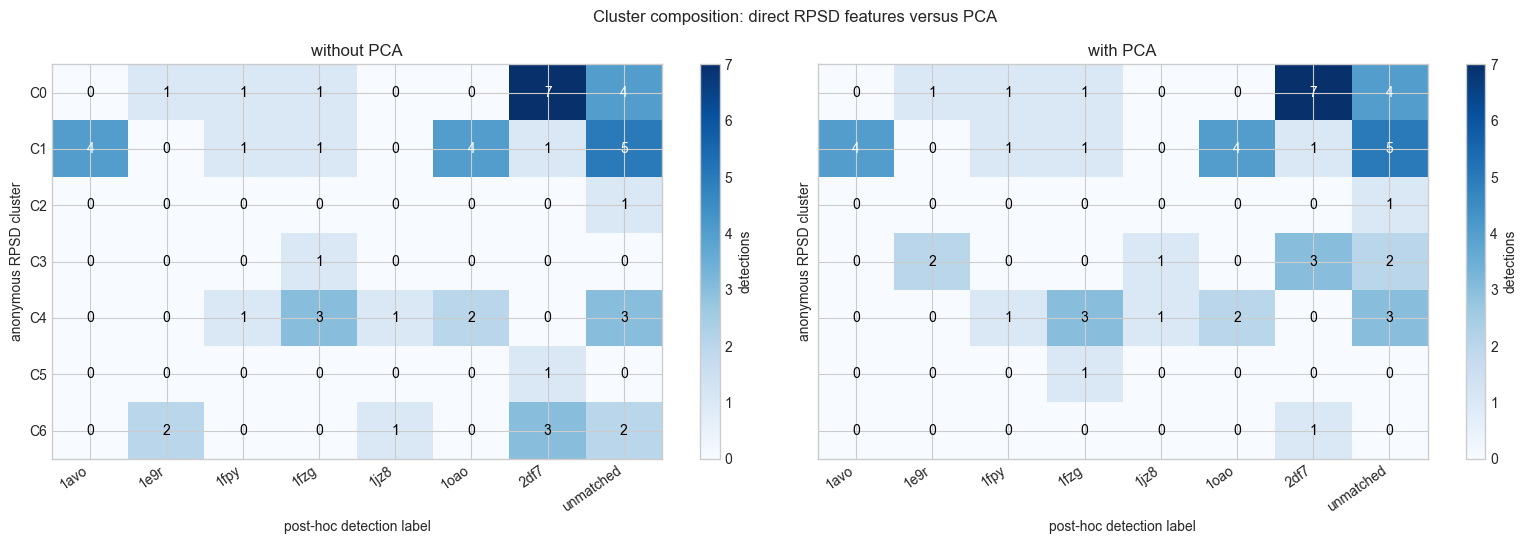

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, result in zip(axes, evaluations):
    confusion = result["confusion"]
    image = ax.imshow(confusion, cmap="Blues", aspect="auto")
    threshold = max(confusion.max() / 2, 1)
    for row in range(CLUSTER_COUNT):
        for column in range(len(EVAL_LABELS)):
            value = confusion[row, column]
            ax.text(
                column,
                row,
                str(value),
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )
    ax.set_xticks(np.arange(len(EVAL_LABELS)), EVAL_LABELS, rotation=35, ha="right")
    ax.set_yticks(np.arange(CLUSTER_COUNT), [f"C{k}" for k in range(CLUSTER_COUNT)])
    ax.set(
        title=result["branch"],
        xlabel="post-hoc detection label",
        ylabel="anonymous RPSD cluster",
    )
    fig.colorbar(image, ax=ax, label="detections")
fig.suptitle("Cluster composition: direct RPSD features versus PCA")
plt.tight_layout()
plt.show()

## 7. PCA projection and cluster sizes

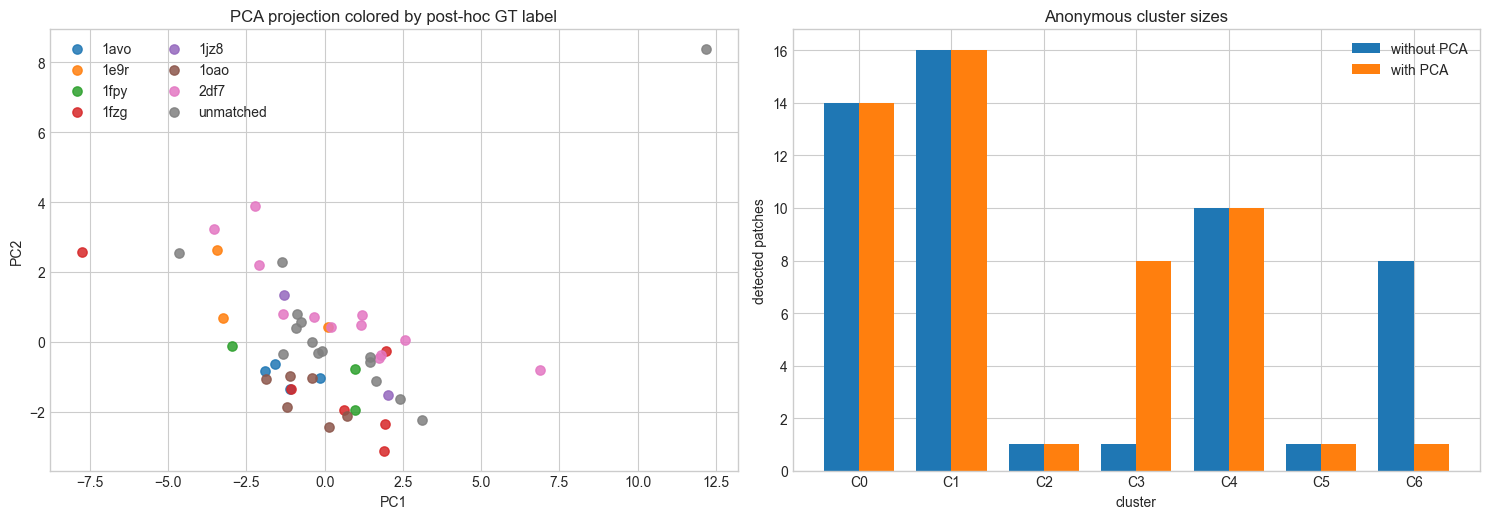

In [9]:
projection = (
    pca_features[:, :2]
    if pca_features.shape[1] >= 2
    else np.column_stack([pca_features[:, 0], np.zeros(len(pca_features))])
)
label_colors = {
    label: plt.cm.tab10(index / 9)
    for index, label in enumerate(EVAL_LABELS)
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.3))
for label in EVAL_LABELS:
    members = posthoc_labels == label
    axes[0].scatter(
        projection[members, 0],
        projection[members, 1],
        label=label,
        color=label_colors[label],
        s=45,
        alpha=0.85,
    )
axes[0].set(
    title="PCA projection colored by post-hoc GT label",
    xlabel="PC1",
    ylabel="PC2",
)
axes[0].legend(ncol=2)

positions = np.arange(CLUSTER_COUNT)
width = 0.38
direct_sizes = np.bincount(clusters_direct, minlength=CLUSTER_COUNT)
pca_sizes = np.bincount(clusters_pca, minlength=CLUSTER_COUNT)
axes[1].bar(positions - width/2, direct_sizes, width, label="without PCA")
axes[1].bar(positions + width/2, pca_sizes, width, label="with PCA")
axes[1].set_xticks(positions, [f"C{k}" for k in positions])
axes[1].set(
    title="Anonymous cluster sizes",
    xlabel="cluster",
    ylabel="detected patches",
)
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Save assignments and diagnostic arrays

In [10]:
assignment_table = pd.DataFrame({
    "detection_rank": np.arange(1, len(picks) + 1),
    "z": picks[:, 0],
    "y": picks[:, 1],
    "x": picks[:, 2],
    "relative_detection_score": picks[:, 3],
    "posthoc_label": posthoc_labels,
    "match_distance_vox": match_distances,
    "cluster_without_pca": clusters_direct,
    "cluster_with_pca": clusters_pca,
})
assignment_table.to_csv(OUTPUT_CSV, index=False)
np.savez_compressed(
    OUTPUT_NPZ,
    radial_points=radial_points,
    detected_rpsds=detected_rpsds,
    standardized_features=standardized_features,
    pca_features=pca_features,
    clusters_direct=clusters_direct,
    clusters_pca=clusters_pca,
    posthoc_labels=posthoc_labels,
)

print(f"Saved assignments: {OUTPUT_CSV.resolve()}")
print(f"Saved RPSD/features: {OUTPUT_NPZ.resolve()}")
display(assignment_table.head(12))

better = metrics_table.sort_values(
    "mapped accuracy on matched detections", ascending=False
).iloc[0]
print(
    f"\nHigher mapped accuracy in this run: {better['branch']} "
    f"({better['mapped accuracy on matched detections']:.3f})."
)
print(
    "Guardrail: the cluster names are assigned only for simulation evaluation. "
    "In real data the clusters remain anonymous, and the supplied K=7 and "
    "51-particle stopping count would both need to be inferred."
)

Saved assignments: /Users/moshemaymon/Documents/thesis/tomotwin_detect_then_cluster_assignments.csv
Saved RPSD/features: /Users/moshemaymon/Documents/thesis/tomotwin_detect_then_cluster_rpsds.npz


,detection_rank,z,y,x,relative_detection_score,posthoc_label,match_distance_vox,cluster_without_pca,cluster_with_pca
0,1,66.0,70.0,70.0,1.000000,unmatched,NaN,2,2
1,2,60.0,58.0,48.0,0.029381,2df7,4.193308,5,6
2,3,75.0,77.0,27.0,0.023482,2df7,2.647638,0,0
3,4,90.0,80.0,71.0,0.021642,2df7,3.185497,0,0
4,5,65.0,105.0,22.0,0.021402,2df7,2.380314,6,3
5,6,107.0,24.0,22.0,0.020450,2df7,3.499841,0,0
6,7,27.0,85.0,19.0,0.020345,2df7,3.102109,1,1
7,8,57.0,113.0,53.0,0.019488,2df7,6.371679,0,0
8,9,35.0,113.0,75.0,0.018664,2df7,5.149335,0,0
9,10,101.0,14.0,39.0,0.018607,2df7,5.182389,0,0



Higher mapped accuracy in this run: without PCA (0.444).
Guardrail: the cluster names are assigned only for simulation evaluation. In real data the clusters remain anonymous, and the supplied K=7 and 51-particle stopping count would both need to be inferred.
